# Notebook 02 — Exploratory Data Analysis & Cleaning

**Goal**: Understand data quality, distributions, and clean for modelling.

---

## What We Do Here

1. **Missing data analysis** — Which stocks have gaps? How do we handle them?
2. **Price distribution** — Are returns normally distributed? (Spoiler: no)
3. **Outlier detection** — Cap extreme moves at 5σ
4. **Correlation analysis** — How do stocks move together?
5. **Stationarity check** — Are returns stationary? (Need for ML)
6. **Survivorship bias** — Discussion of what we can/can't control
7. **Save cleaned data** — Output to `data/interim/`

## Why This Matters

Garbage in → garbage out. ML models are sensitive to:
- Missing values (NaN propagates through features)
- Outliers (one 50% gap-up can dominate gradient)
- Non-stationarity (models assume training ≈ test distribution)

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import TickerUniverse, DataDownloader, DataCleaner
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load All Raw Data

Load every downloaded ticker into a dictionary of DataFrames.
We'll assess data availability across the full universe.

In [2]:
universe = TickerUniverse()
downloader = DataDownloader(universe)

# Load all available data
all_data = downloader.load_all()
print(f"Loaded {len(all_data)} tickers\n")

# Create summary DataFrame
summary_rows = []
for ticker, df in all_data.items():
    summary_rows.append({
        "ticker": ticker,
        "start_date": df.index[0],
        "end_date": df.index[-1],
        "trading_days": len(df),
        "missing_pct": df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100,
        "avg_volume": df["Volume"].mean() if "Volume" in df.columns else 0,
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.describe())

Loaded 124 tickers

                          start_date             end_date  trading_days  \
count                            124                  124    124.000000   
mean   2017-01-03 12:11:36.774193664  2026-02-11 00:00:00   2250.233871   
min              2016-02-15 00:00:00  2026-02-11 00:00:00     64.000000   
25%              2016-02-15 00:00:00  2026-02-11 00:00:00   2469.000000   
50%              2016-02-15 00:00:00  2026-02-11 00:00:00   2469.000000   
75%              2016-02-15 00:00:00  2026-02-11 00:00:00   2469.000000   
max              2025-11-12 00:00:00  2026-02-11 00:00:00   2469.000000   
std                              NaN                  NaN    524.704859   

       missing_pct    avg_volume  
count        124.0  1.240000e+02  
mean           0.0  9.919309e+06  
min            0.0  2.729170e+04  
25%            0.0  1.301572e+06  
50%            0.0  3.464862e+06  
75%            0.0  1.441492e+07  
max            0.0  8.211593e+07  
std            0.0  1.40

## Step 2 — Missing Data Analysis

**Why it matters**: Missing OHLCV data can create fake features (NaN RSI, NaN MACD).

**Our approach**:
- Forward-fill gaps ≤ 5 days (non-trading days, holidays)
- Drop tickers with < 500 trading days (insufficient history)
- Log the quality issues for transparency

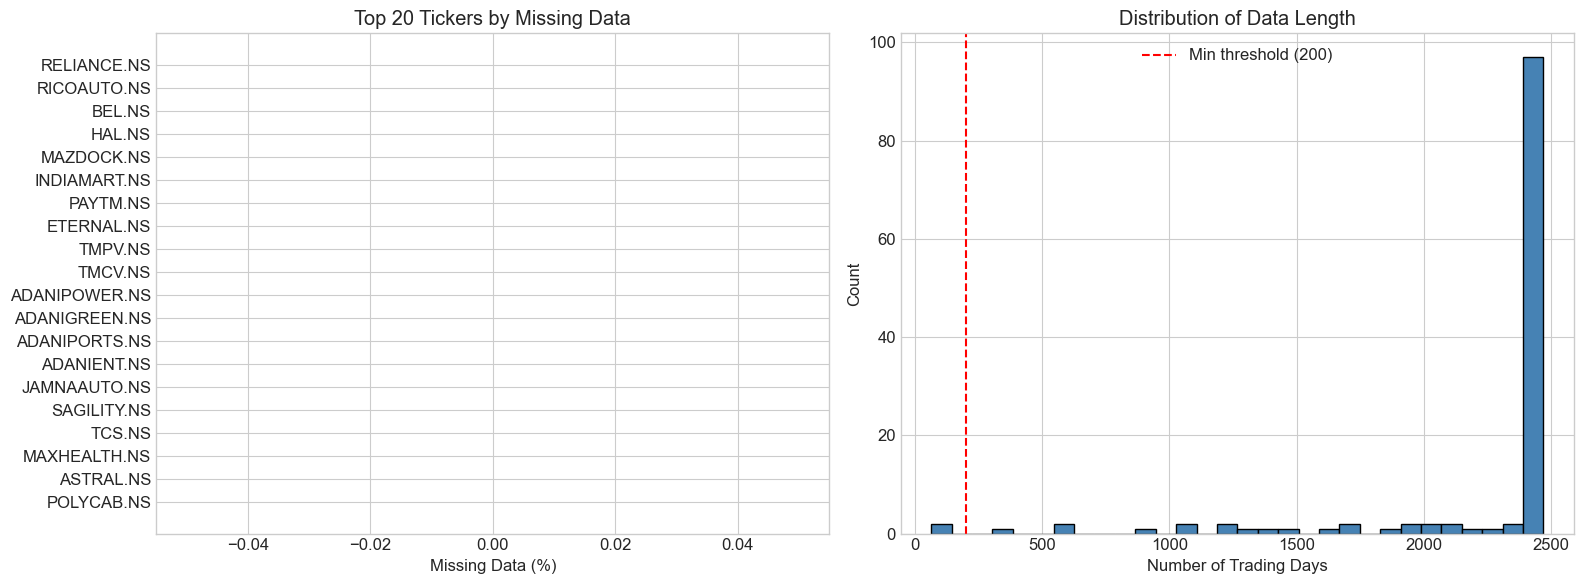


Tickers with < 200 days (will be dropped): 2
 ticker  trading_days
TMCV.NS            64
TMPV.NS            81


In [3]:
# Missing data by ticker — show top 20 worst
missing_sorted = summary_df.sort_values("missing_pct", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — top 20 missing
top20 = missing_sorted.head(20)
axes[0].barh(top20["ticker"], top20["missing_pct"], color="coral")
axes[0].set_xlabel("Missing Data (%)")
axes[0].set_title("Top 20 Tickers by Missing Data")
axes[0].invert_yaxis()

# Histogram of trading days
axes[1].hist(summary_df["trading_days"], bins=30, color="steelblue", edgecolor="black")
axes[1].axvline(200, color="red", linestyle="--", label="Min threshold (200)")
axes[1].set_xlabel("Number of Trading Days")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Data Length")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "missing_data_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

short_tickers = summary_df[summary_df["trading_days"] < 200]
print(f"\nTickers with < 200 days (will be dropped): {len(short_tickers)}")
if len(short_tickers) > 0:
    print(short_tickers[["ticker", "trading_days"]].to_string(index=False))

## Step 3 — Return Distribution Analysis

Stock returns are famously **NOT normally distributed**:
- **Fat tails**: Extreme moves happen more often than a Gaussian predicts
- **Negative skew**: Large drops are more common than large rallies
- **Leptokurtic**: Higher kurtosis than normal (excess kurtosis > 0)

This matters because:
- MSE loss assumes Gaussian errors → may underweight tails
- VaR/CVaR calculations need to account for fat tails
- Position sizing should be conservative due to tail risk

Total return observations: 278,762
Mean daily return:  0.0948%
Std daily return:   2.2286%
Skewness:           0.940
Kurtosis (excess):  43.264
Min daily return:   -51.21%
Max daily return:   104.06%


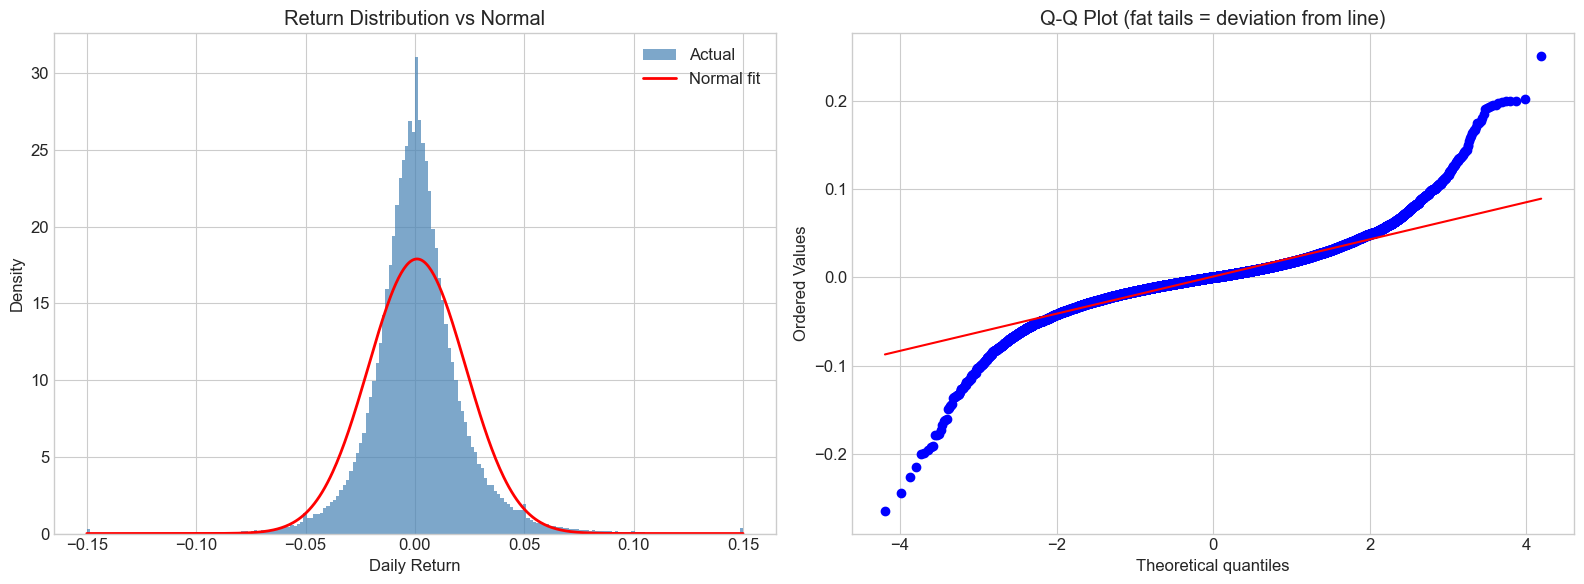

In [4]:
# Compute daily returns for all tickers
returns_list = []
for ticker, df in all_data.items():
    if "Close" in df.columns and len(df) > 100:
        ret = df["Close"].pct_change().dropna()
        returns_list.append(ret.rename(ticker))

returns_df = pd.concat(returns_list, axis=1)

# Aggregate stats
agg_returns = returns_df.stack()
print(f"Total return observations: {len(agg_returns):,}")
print(f"Mean daily return:  {agg_returns.mean():.4%}")
print(f"Std daily return:   {agg_returns.std():.4%}")
print(f"Skewness:           {agg_returns.skew():.3f}")
print(f"Kurtosis (excess):  {agg_returns.kurtosis():.3f}")
print(f"Min daily return:   {agg_returns.min():.2%}")
print(f"Max daily return:   {agg_returns.max():.2%}")

# Plot distribution vs normal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(agg_returns.clip(-0.15, 0.15), bins=200, density=True,
             alpha=0.7, color="steelblue", label="Actual")
x = np.linspace(-0.15, 0.15, 500)
axes[0].plot(x, stats.norm.pdf(x, agg_returns.mean(), agg_returns.std()),
             "r-", lw=2, label="Normal fit")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].set_title("Return Distribution vs Normal")
axes[0].legend()

# QQ plot
stats.probplot(agg_returns.dropna().sample(min(50000, len(agg_returns))),
               dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (fat tails = deviation from line)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 — Run Data Cleaner

The `DataCleaner` class performs:

1. **Forward-fill** small gaps (≤ 5 trading days)
2. **Adjust prices** to Adjusted Close if available
3. **Cap outliers** at ±5σ (standard deviations from mean return)
4. **Filter tickers** with < 200 trading days
5. **Generate quality report**

Cleaned data is saved to `data/interim/`

In [9]:
cleaner = DataCleaner()

# Clean all tickers (also saves to interim dir automatically)
cleaned_data = cleaner.clean_all(all_data)

# Identify dropped tickers
quality_issues = [t for t in all_data if t not in cleaned_data]

print(f"\nCleaned tickers:  {len(cleaned_data)}")
print(f"Dropped tickers:  {len(quality_issues)}")

if quality_issues:
    print(f"\nDropped: {quality_issues}")

Cleaning 124 tickers...


Cleaning:  85%|████████▌ | 106/124 [00:00<00:00, 183.93it/s]

  ⚠ TMCV.NS: only 64 days — SKIPPED (need 200)
  ⚠ TMPV.NS: only 81 days — SKIPPED (need 200)


Cleaning: 100%|██████████| 124/124 [00:00<00:00, 166.17it/s]


Cleaning complete: 122 passed, 2 dropped
Dropped: ['TMCV.NS', 'TMPV.NS']

Cleaned tickers:  122
Dropped tickers:  2

Dropped: ['TMCV.NS', 'TMPV.NS']


## Step 5 — Quality Report

Let's generate a comprehensive quality report for the cleaned data.

In [6]:
report_df = cleaner.quality_report(cleaned_data)

print("Data Quality Summary:")
print("=" * 60)
print(report_df.describe(include="all").to_string())

print(f"\n\nTop 10 stocks by data length:")
print(report_df.nlargest(10, "Rows")[["Ticker", "Rows", "Missing%"]].to_string(index=False))

Data Quality Summary:
             Ticker         Rows       Start         End Missing%  Avg_Volume Status
count           122   122.000000         122         122      122         122    122
unique          122          NaN          26           1        1         122      1
top     RELIANCE.NS          NaN  2016-02-15  2026-02-11    0.00%  17,883,361     OK
freq              1          NaN          97         122      122           1    122
mean            NaN  2285.934426         NaN         NaN      NaN         NaN    NaN
std             NaN   447.426816         NaN         NaN      NaN         NaN    NaN
min             NaN   311.000000         NaN         NaN      NaN         NaN    NaN
25%             NaN  2469.000000         NaN         NaN      NaN         NaN    NaN
50%             NaN  2469.000000         NaN         NaN      NaN         NaN    NaN
75%             NaN  2469.000000         NaN         NaN      NaN         NaN    NaN
max             NaN  2469.000000         Na

## Step 6 — Correlation Heatmap

Understanding stock correlations helps with:
- **Diversification**: Low-correlation stocks reduce portfolio risk
- **Feature engineering**: Highly correlated features add noise, not signal
- **Sector clustering**: Stocks within sectors tend to co-move

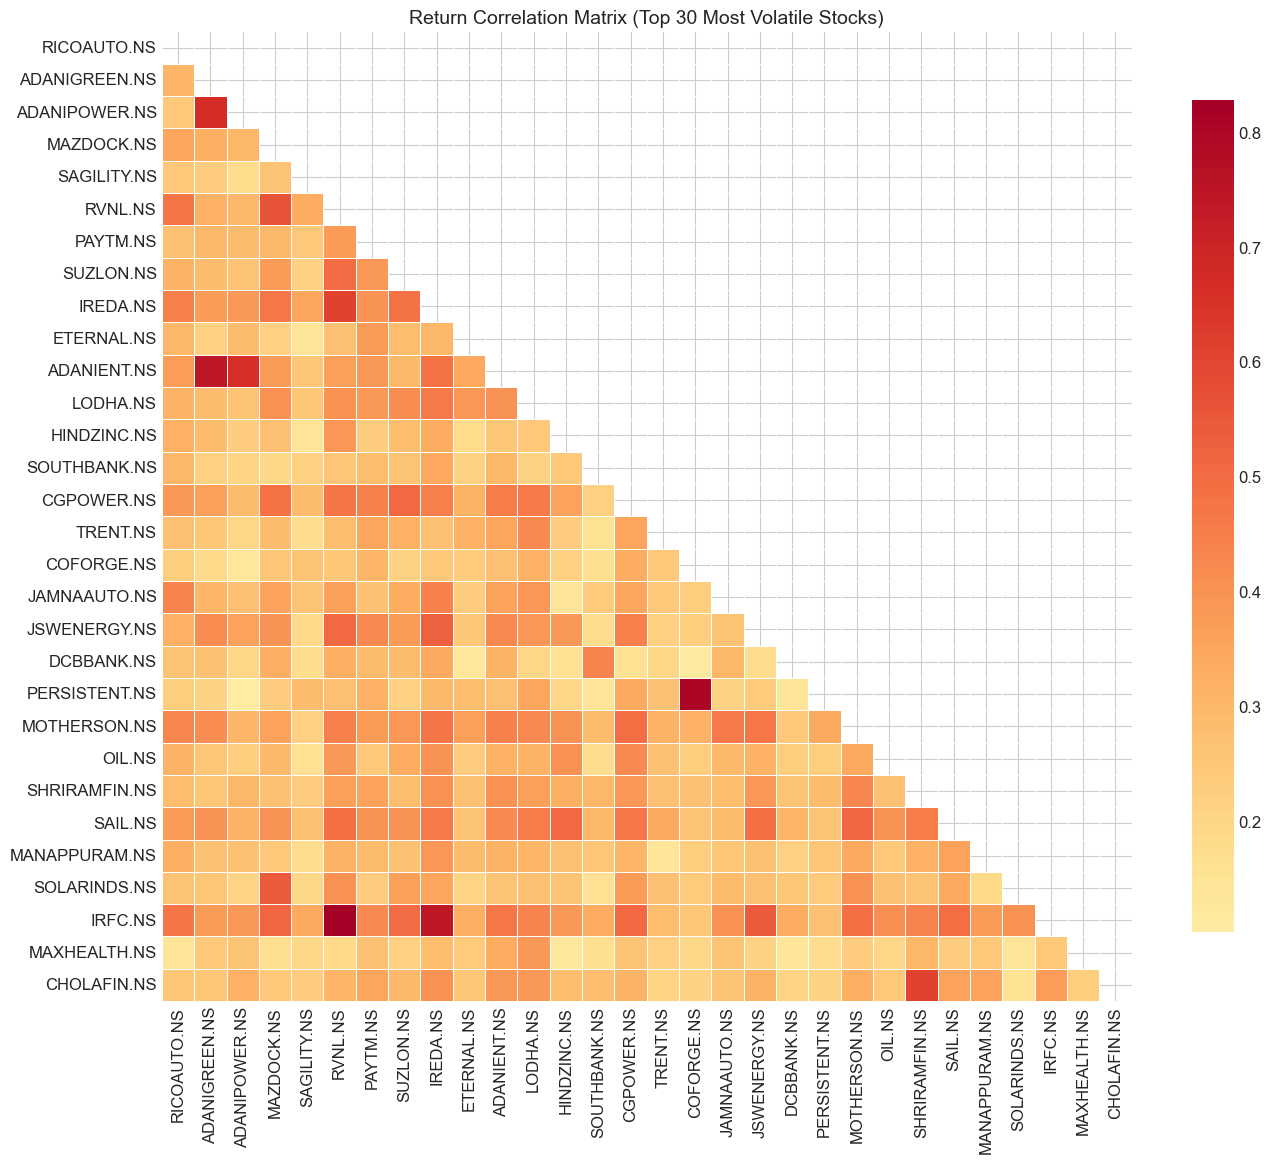


Average pairwise correlation: 0.315
(Lower = better diversification potential)


In [7]:
# Build close-price returns matrix
close_returns = {}
for ticker, df in cleaned_data.items():
    if len(df) > 200:
        close_returns[ticker] = df["Close"].pct_change()

ret_matrix = pd.DataFrame(close_returns).dropna()

# Correlation matrix — show top 30 tickers for readability
top30 = ret_matrix.std().nlargest(30).index
corr = ret_matrix[top30].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdYlBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, fmt=".2f")
ax.set_title("Return Correlation Matrix (Top 30 Most Volatile Stocks)", fontsize=14)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Average pairwise correlation
avg_corr = corr.values[np.triu_indices_from(corr.values, k=1)].mean()
print(f"\nAverage pairwise correlation: {avg_corr:.3f}")
print("(Lower = better diversification potential)")

## Step 7 — Survivorship Bias Discussion

### What is Survivorship Bias?

Our ticker list only contains companies that are **currently listed on NSE**.
Companies that went bankrupt, delisted, or merged are not in our data.

This means our backtest results are **optimistically biased** because:
- We wouldn't have known in 2019 which stocks would survive until 2024
- Failed companies (which we'd have lost money on) are not in the dataset

### How We Mitigate (partially)

1. **Walk-forward CV**: We only use data available at each point in time
2. **Conservative position sizing**: Half-Kelly with 10% max per stock
3. **Diversification**: 120+ stocks across 5 sectors
4. **Transaction costs**: Included in all backtest results
5. **Acknowledgement**: We clearly state this limitation in our final report

### Proper Solution (out of scope)

A production system would use a **point-in-time universe** from a vendor like
CRSP/Compustat (US), ProwessIQ (India), or Bloomberg — which includes delisted
companies as they were known at each historical date.

In [8]:
# Verify: how many stocks have full 5-year history?
full_history = sum(1 for df in cleaned_data.values() if len(df) >= 1200)
partial = sum(1 for df in cleaned_data.values() if 500 <= len(df) < 1200)

print(f"Stocks with full 5-year history (≥1200 days): {full_history}")
print(f"Stocks with partial history (500-1200 days):   {partial}")
print(f"Total usable stocks:                           {len(cleaned_data)}")
print(f"\n⚠️  Survivorship bias is present. See discussion above.")

Stocks with full 5-year history (≥1200 days): 115
Stocks with partial history (500-1200 days):   6
Total usable stocks:                           122

⚠️  Survivorship bias is present. See discussion above.


## ✅ EDA & Cleaning Complete!

**What we learned:**
1. Returns are non-normal with fat tails and negative skew
2. Most stocks have good data quality (few missing values)
3. Sector correlations exist — diversification helps
4. Survivorship bias is acknowledged but mitigated

**Cleaned data saved to:** `data/interim/`

**Next:** Proceed to **Notebook 03 — Feature Engineering**

---
*Educational project. Not financial advice.*